In [1]:
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
DATA_RAW = PROJECT_ROOT / "data" / "raw"
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
BOLTZ_OUT = PROJECT_ROOT / "boltz_outputs"
FIGURES = PROJECT_ROOT / "figures"

In [2]:
import pandas as pd 

df = pd.read_csv(DATA_PROCESSED / "boltz_subset.csv")
ids = df["Molecule ChEMBL ID"]

In [3]:
# Collect paths for affinity predictions and confidence estimations
affinity_paths = {}
confidence_paths = {}
for i in ids:
    # affinity
    path_aff = BOLTZ_OUT / f"boltz_results_{i}" / "predictions" / i / f"affinity_{i}.json"
    affinity_paths[i] = path_aff

    # confidence
    path_con = BOLTZ_OUT / f"boltz_results_{i}" / "predictions" / i / f"confidence_{i}_model_0.json"
    confidence_paths[i] = path_con

In [4]:
# Add prediction and supprting data to dataframe
import json

def read_json(path, key):
    try: 
        return json.loads(path.read_text()).get(key)
    except (FileNotFoundError, json.JSONDecodeError, TypeError):
        return None

# Affinities to table
df["Affinity Pred"] = df["Molecule ChEMBL ID"].apply(lambda p: read_json(affinity_paths[p], "affinity_pred_value"))
df["Affinity Prob Binary"] = df["Molecule ChEMBL ID"].apply(lambda p: read_json(affinity_paths[p], "affinity_probability_binary"))

# Confidences to table
df["Confidence Score"] = df["Molecule ChEMBL ID"].apply(lambda p: read_json(confidence_paths[p], "confidence_score"))
df["Confidence ipTM"] = df["Molecule ChEMBL ID"].apply(lambda p: read_json(confidence_paths[p], "ptm"))
df["Confidence Ligand ipTM"] = df["Molecule ChEMBL ID"].apply(lambda p: read_json(confidence_paths[p], "iptm"))

In [5]:
# Convert the affinity predictions (IC50 in µM) to match pIC50 (IC50 in M)
df["Boltz pChEMBL"] = 6 - df["Affinity Pred"]

In [6]:
df.to_csv(DATA_PROCESSED / "boltz_preds.csv" , index=False)

### Predicted and experimental correlation (noncovalent only)

What is the statisticcal reliability of the affinity estimation?

The Pearson correlation coefficient measures the strength of the linear relationship between the Boltz-2 prediction and the median experimental measurement.

Spearman's rank correlation measures the ability of Boltz-2 to correctly rank the compounds by potency.

In [7]:
# Pearson correlation
from scipy.stats import pearsonr
import numpy as np

# Exclude row with missing data (CHEMBL58)
df = df[df["Affinity Pred"].notna()]

noncovalent = df[~df["Acrylamide"]]

experiment = noncovalent["pChEMBL Median"]
pred = noncovalent["Boltz pChEMBL"]

pearson_corr, pearson_pval = pearsonr(experiment, pred)
print(f"Pearson Correlation: {pearson_corr:.4f}, P-value: {pearson_pval:.4f}")

Pearson Correlation: 0.3437, P-value: 0.0145


In [8]:
# Spearman correlation
from scipy.stats import spearmanr

spearman_corr, spearman_pval = spearmanr(experiment, pred)
print(f"Spearman Correlation: {spearman_corr:.4f}, P-value: {spearman_pval:.4f}")

Spearman Correlation: 0.2329, P-value: 0.1036


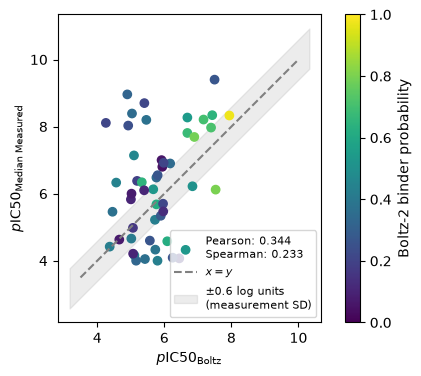

In [9]:
# Scatter plot of prediciton vs. measurement
import matplotlib.pyplot as plt

markers = {
    "4-Anilinoquinazoline-like": "o",
    "Aminopurine-like": "s",
    "Covalent": "^",
    "Monocyclic": "D",
    "Other": "v",
}

fig, ax = plt.subplots(figsize=(6,4))

x = np.linspace(3.5,10,num=5)
y=x

sc = ax.scatter(pred, experiment, c=noncovalent["Affinity Prob Binary"], 
            label=f"Pearson: {pearson_corr:.3f}\nSpearman: {spearman_corr:.3f}",
            cmap="viridis", vmin=0, vmax=1)
ax.plot(x, y, label="$x=y$", color="gray", ls="--")
plt.colorbar(sc, ax=ax, label="Boltz-2 binder probability")

lims = [min(ax.get_xlim()[0], ax.get_ylim()[0]),
        max(ax.get_xlim()[1], ax.get_ylim()[1])]
ax.fill_between(lims, [l - 0.6 for l in lims], [l + 0.6 for l in lims],
                color="grey", alpha=0.15, zorder=0,
                label="±0.6 log units\n(measurement SD)")

ax.set_aspect("equal")
ax.set_xlabel(r"$p\text{IC}50_{\text{Boltz}}$")
ax.set_ylabel(r"$p\text{IC}50_{\text{Median Measured}}$")
plt.legend(loc=4, fontsize=8)

plt.savefig(FIGURES / "pred_vs_exp_covalent.png")

There is uncertainty on the experimental values. The shaded region indicates the typical spread between independent measurements of the same compound. 

In [10]:
len(noncovalent)

50

In [11]:
# Use bootstrapping to get a confidence interval on the correlations
from scipy.stats import bootstrap
import numpy as np

x = pred.to_numpy()
y = experiment.to_numpy()

pear_res = bootstrap((x, y), lambda a, b: pearsonr(a, b)[0],
                paired=True, n_resamples=500, random_state=92)
spear_res = bootstrap((x, y), lambda a, b: spearmanr(a, b)[0],
                paired=True, n_resamples=500, random_state=92)
print("Pearson,", pear_res.confidence_interval)
print("Spearman,", spear_res.confidence_interval)

Pearson, ConfidenceInterval(low=0.10102415411656823, high=0.6000379921219251)
Spearman, ConfidenceInterval(low=-0.019990400773738363, high=0.49487966685153106)


For the 50 noncovalent predictions, the Boltz-2 predicted affinities showed weak positive correlation with the median experimental measurements (Pearson: 0.34 [0.10, 0.60], p: 0.01, Spearman: 0.23 [-0.02, 0.49], p: 0.10). The Spearman result is not significant at the conventional 5% threshold, and the bootstrap confidence interval includes zero. At this sample size, the data cannot distinguish a genuine moderate correlation to no correlation at all. The Pearson interval narrowly excludes zero on the bootstrapped interval, and spans everything from negligible to moderately strong. The data are consistent with anything from no relationship to a moderate one and a clear conclusion on Boltz-2's ranking abilities requires a larger sample size.

Note that the measured values themselves carry uncertainty, creating an upper bound on the correlation model. Replicate measurements of the same compound across independent publications differ by a median of 0.64 log units (compounds with >=5 measurements). See `notebook/chembl_data.ipynb`. 

### Can Boltz-2 separate binders from nonbinders?

ROC-AUC = 0.664  (n=50, 16 positives)
ConfidenceInterval(low=0.49681333504919534, high=0.8378360250773157)


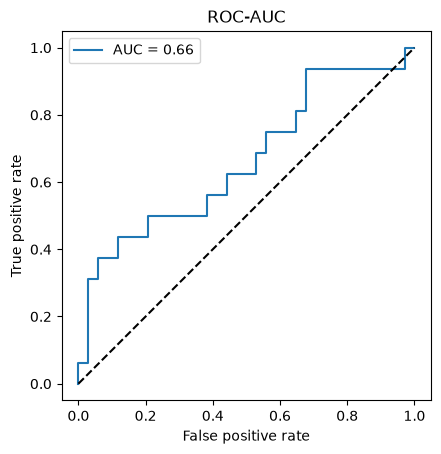

In [12]:
# Can Boltz-2 rank binders? pChEMBL cut off of 7
from sklearn.metrics import roc_auc_score, roc_curve

# define "binder"
y_true = (noncovalent["pChEMBL Median"] >= 7).astype(int)     
y_score = noncovalent["Affinity Prob Binary"]

auc = roc_auc_score(y_true, y_score)
print(f"ROC-AUC = {auc:.3f}  (n={len(noncovalent)}, {y_true.sum()} positives)")

fig, ax = plt.subplots()

fpr, tpr, _ = roc_curve(y_true, y_score)
ax.plot(fpr, tpr, label=f"AUC = {auc:.2f}")
ax.plot([0,1],[0,1],"k--")
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")
plt.legend()
plt.gca().set_aspect("equal")
ax.set_title("ROC-AUC")
plt.savefig(FIGURES / "roc_auc.png")

# Bootstrap interval for AUC
res = bootstrap((y_true.to_numpy(), y_score.to_numpy()),
                lambda a, b: roc_auc_score(a, b),
                paired=True, n_resamples=500, random_state=42)
print(res.confidence_interval)

Boltz-2's binder probability distinguished potent compounds (pChEMBL >= 7) from the rest with ROC-AUC = 0.66 (n = 50, 16 positives; 95% CI [0.50, 0.84]). The lower bound sits at the random-classifier value, so while the point estimate suggests weak discriminative ability, the result is not statistically distinguishable from chance at this sample size. 

Therefore, it's unclear whether Boltz-2 discriminates likely binders from unlikely ones on this target. Note that the subset is constructed in a way that makes discrimination particularly difficult.

In [13]:
# The point AUC depends on the threshhold
for t in [6.5, 7.0, 7.5, 8.0]:
    yt = (noncovalent["pChEMBL Median"] >= t).astype(int)
    if 5 < yt.sum() < len(yt) - 5:
        print(t, round(roc_auc_score(yt, noncovalent["Affinity Prob Binary"]), 3), yt.sum())

6.5 0.573 20
7.0 0.664 16
7.5 0.702 14
8.0 0.59 11


### How does Boltz-2 compare to a trivial benchmark?



In [14]:
print("heavy atoms:", spearmanr(noncovalent["pChEMBL Median"], noncovalent["Heavy Atoms"])[0].round(3))
print("MW:         ", spearmanr(noncovalent["pChEMBL Median"], noncovalent["Molecular Weight"])[0].round(3))

heavy atoms: 0.079
MW:          0.057


Molecular size alone gives almost no signal on this subset (Spearman = 0.08 for heavy atom count, 0.06 for molecular weight), so Boltz-2 is not simply recovering the "bigger binds tighter" trend that often inflates affinity benchmarks. That size has so little predictive power here is a consequence of the subset design: compounds were selected for structural diversity within stratified potency bins, which deliberately decouples size from potency.

### How does Boltz-2 compare to a QSAR benchmark?



In [15]:
from sklearn.ensemble import RandomForestRegressor
from rdkit.Chem import rdFingerprintGenerator, PandasTools

gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)

def fp_array(mols):
    return np.array([gen.GetFingerprintAsNumPy(m) for m in mols])

# hold out the computed subset
held_out = set(noncovalent["Clean InchiKey"])
df = pd.read_csv(DATA_PROCESSED / "egfr_clean.csv")
PandasTools.AddMoleculeColumnToFrame(df, smilesCol="Clean Smiles", 
                molCol="RDkit Mol", includeFingerprints=True)
PandasTools.AddMoleculeColumnToFrame(noncovalent, smilesCol="Clean Smiles", 
                molCol="RDkit Mol", includeFingerprints=True)
train = df[~df["Clean InchiKey"].isin(held_out)]

print(len(train), "training compounds,", len(noncovalent), "test")

X_train = fp_array(train["RDkit Mol"])
y_train = train["pChEMBL Median"]

X_test = fp_array(noncovalent["RDkit Mol"])
y_test = noncovalent["pChEMBL Median"]

rf = RandomForestRegressor(n_estimators=500, n_jobs=-1, random_state=92)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)

rho, p = spearmanr(y_test, pred_rf)
print(f"Random forest: Spearman rho = {rho:.3f}, p = {p:.3g}, n = {len(y_test)}")

6659 training compounds, 50 test
Random forest: Spearman rho = 0.761, p = 1.36e-10, n = 50


In [16]:
# Confidence interval
res = bootstrap((y_test.to_numpy(), pred_rf),
                lambda a, b: spearmanr(a, b)[0],
                paired=True, n_resamples=500, random_state=92)
print(res.confidence_interval)

ConfidenceInterval(low=0.5893028469489416, high=0.8614624295675072)


In [17]:
from rdkit import DataStructs

# how similar is each test compound to its nearest training neighbour?
test_fps = [gen.GetFingerprint(m) for m in noncovalent["RDkit Mol"]]
train_fps = [gen.GetFingerprint(m) for m in train["RDkit Mol"]]
max_sim = np.array([max(DataStructs.BulkTanimotoSimilarity(f, train_fps)) for f in test_fps])
print(np.percentile(max_sim, [50, 90, 100]).round(2))
print((max_sim > 0.8).sum(), "test compounds with a very close training analog")

[0.72 0.86 0.98]
16 test compounds with a very close training analog


### How does Boltz-2/Random Forest compare to a similarity benchmark?

In [18]:
# Is random forest merely interpolating between near analogues?
nn_idx = [np.argmax(DataStructs.BulkTanimotoSimilarity(f, train_fps)) for f in test_fps]
pred_nn = train["pChEMBL Median"].iloc[nn_idx].to_numpy()
print(spearmanr(noncovalent["pChEMBL Median"], pred_nn))

# Confidence interval
res = bootstrap((y_test.to_numpy(), pred_nn),
                lambda a, b: spearmanr(a, b)[0],
                paired=True, n_resamples=500, random_state=92)
print(res.confidence_interval)

SignificanceResult(statistic=0.781985403664944, pvalue=2.0223303539282187e-11)
ConfidenceInterval(low=0.5551480212247784, high=0.878389869221502)


The Random Forest (Pearson = 0.76, CI [0.58,0.86]) achieves a far higher correlation, at first glance. Although there is a low Tanimoto similarity in the subset (0.14), there is very high similarity to compounds within the training set of ~6,000 compounds. Most of the compounds have a close analogue in the training set, since the 50th precentile has a Tanimoto similarity of 0.72. 

In fact, the nearest neighbor yields an even better Pearson correlation (Pearson = 0.78, CI [0.56,0.88]) than Random Forest. So, what happens when close analogues are removed?

In [19]:
noncovalent["Max Train Sim"] = max_sim
noncovalent["RF Pred"] = pred_rf

for lo, hi in [(0, 0.6), (0.6, 0.8), (0.8, 1.0)]:
    g = noncovalent[(max_sim >= lo) & (max_sim < hi)]
    if len(g) > 5:
        r_rf = spearmanr(g["pChEMBL Median"], g["RF Pred"])[0]
        r_bz = spearmanr(g["pChEMBL Median"], g["Boltz pChEMBL"])[0]
        print(f"sim {lo}-{hi}: n={len(g)}  RF={r_rf:.2f}  Boltz={r_bz:.2f}")

sim 0-0.6: n=17  RF=0.49  Boltz=-0.13
sim 0.6-0.8: n=17  RF=0.79  Boltz=0.12
sim 0.8-1.0: n=16  RF=0.78  Boltz=0.62


In [20]:
# Confidence interval for the low similarity bin
m = max_sim < 0.6
g = noncovalent[m]
res = bootstrap((g["pChEMBL Median"].to_numpy(), g["Boltz pChEMBL"].to_numpy()),
                lambda a, b: spearmanr(a, b)[0], paired=True,
                n_resamples=5000, random_state=92)
print(res.confidence_interval)

ConfidenceInterval(low=-0.5776391998585638, high=0.4136750477317519)


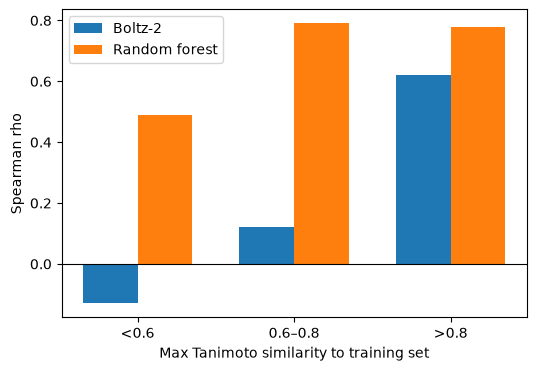

In [21]:
bins = ["<0.6", "0.6–0.8", ">0.8"]
boltz_vals = [-0.13, 0.12, 0.62]
rf_vals = [0.49, 0.79, 0.78]

x = np.arange(3); w = 0.35
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(x - w/2, boltz_vals, w, label="Boltz-2")
ax.bar(x + w/2, rf_vals, w, label="Random forest")
ax.axhline(0, color="k", lw=0.8)
ax.set_xticks(x); ax.set_xticklabels(bins)
ax.set_xlabel("Max Tanimoto similarity to training set")
ax.set_ylabel("Spearman rho")
ax.legend()

plt.savefig(FIGURES / "Boltz2_RF_Tanimoto_similarity.png")

Both Boltz-2 and Random Forest depend on chemical familiarity for much of the correlation. In fact, Boltz-2 is far more sensitive to loss of analogue than Random Forest.

**So, does any of the structural modelling by Boltz-2 beat knowing which substructures are present?**

There's no evidence for that here. In fact, Boltz-2's performance depends on chemical familiarity even more than the Random Forest's does. 

Part of this is due to training set overlap. Boltz-2 was trained on public binding data, including ChEMBL. Part of this is due to general challenges in predicting novel chemistry. 

The poor ranking is probably to be expected for a target with such diverse binding modes. Others have found previously that Boltz-2 has poor binding affinity correlation in targets with diverse binding modes. Therefore, its recommended not to use Boltz-2 for binding predictions unless the target has a well-defined binding pocket.

[Wan et al. 2026 On the Reliability of AI Methods in Drug Discovery: Evaluation of Boltz-2 for Structure and Binding Affinity Prediction]. 